In [1]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

I0000 00:00:1780580762.058132  148824 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)


I0000 00:00:1780580767.741103  148824 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:2b:00.0, compute capability: 8.6


In [3]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [4]:
BUFFER_SIZE = 1000

shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)

train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [5]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)

test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

I0000 00:00:1780580771.123329  149099 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


(6000, 28, 28, 1) (6000,)


W0000 00:00:1780580771.480018  149102 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [6]:
input_size = 784
output_size = 10
hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/home/kacper/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1
          )

Epoch 1/30


I0000 00:00:1780580777.026368  149049 service.cc:153] XLA service 0x756938031a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780580777.026431  149049 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780580777.048598  149049 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780580777.170077  149049 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780580777.179008  149049 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1368__.13
I0000 00:00:1780580777.196146  149049 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

 36/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3247 - loss: 2.0592

I0000 00:00:1780580782.316198  149049 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


540/540 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8766 - loss: 0.4275 - val_accuracy: 0.9408 - val_loss: 0.2150
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9481 - loss: 0.1779 - val_accuracy: 0.9508 - val_loss: 0.1646
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9591 - loss: 0.1364 - val_accuracy: 0.9588 - val_loss: 0.1473
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9664 - loss: 0.1139 - val_accuracy: 0.9588 - val_loss: 0.1393
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9720 - loss: 0.0957 - val_accuracy: 0.9640 - val_loss: 0.1217
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9740 - loss: 0.0850 - val_accuracy: 0.9650 - val_loss: 0.1223
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s -321us/step - accuracy: 0.9784 - loss: 0.0730 - val_accuracy: 0.9670 - val_loss: 0.1172
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9805 - loss: 0.0654 - val_accuracy: 0.9697 -

In [8]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Tesst loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9709 - loss: 0.1045
Tesst loss: 0.10. Test accuracy: 97.09%


In [9]:
def sprawdz_grupe(nazwy_plikow, wytrenowany_model):
    n = len(nazwy_plikow)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, nazwa_pliku in zip(axes, nazwy_plikow):
        img = cv2.imread(nazwa_pliku, cv2.IMREAD_GRAYSCALE)
        if img is None:
            ax.set_title(f"Brak pliku\n{nazwa_pliku.split('/')[-1]}", fontsize=10)
            ax.axis('off')
            continue

        if np.mean(img) > 127:
            tryb = cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        else:
            tryb = cv2.THRESH_BINARY + cv2.THRESH_OTSU
        _, img_bin = cv2.threshold(img, 0, 255, tryb)

        coords = cv2.findNonZero(img_bin)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            img_bin = img_bin[y:y+h, x:x+w]
            pad = max(w, h) // 4
            img_bin = cv2.copyMakeBorder(img_bin, pad, pad, pad, pad, cv2.BORDER_CONSTANT)

        img_resized = cv2.resize(img_bin, (28, 28)).astype(np.float32) / 255.
        img_reshaped = img_resized.reshape(1, 28, 28, 1)
        predictions = wytrenowany_model.predict(img_reshaped, verbose=0)

        predicted_digit = np.argmax(predictions)
        confidence = np.max(predictions) * 100

        ax.imshow(img_resized, cmap='gray')
        ax.set_title(f"{nazwa_pliku.split('/')[-1]}\n→ {predicted_digit} ({confidence:.1f}%)", fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

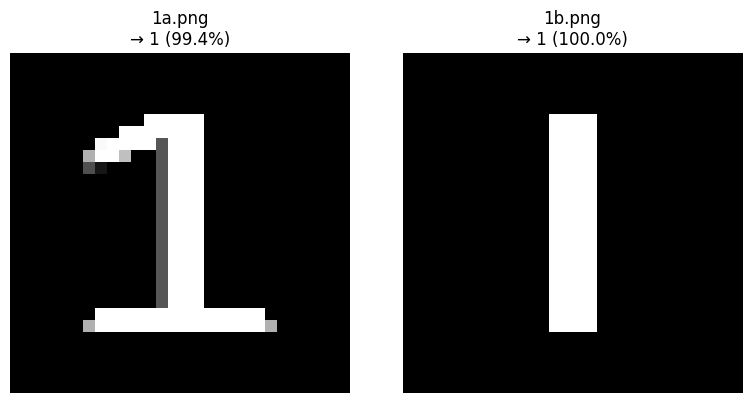

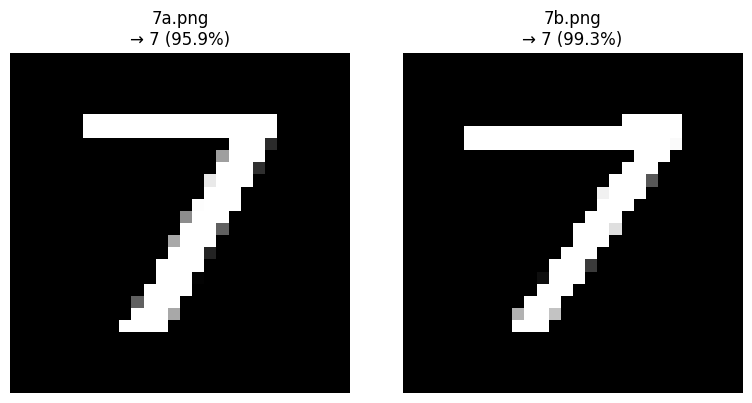

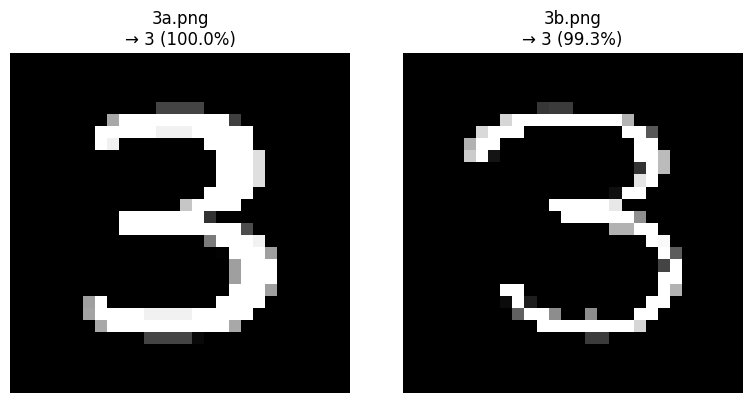

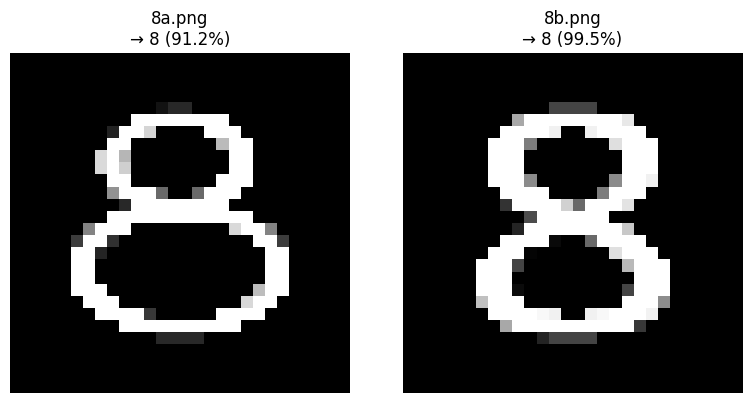

In [15]:
sprawdz_grupe(['obrazki/1a.png', 'obrazki/1b.png'], model)
sprawdz_grupe(['obrazki/7a.png', 'obrazki/7b.png'], model)
sprawdz_grupe(['obrazki/3a.png', 'obrazki/3b.png'], model)
sprawdz_grupe(['obrazki/8a.png', 'obrazki/8b.png'], model)